In [85]:
import gamry_parser
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import make_splrep
import math
from scipy.signal import savgol_filter

main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data")
file_list = list(main_dir.rglob('*_8H.DTA'))

all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    eis_data = {
        'name':str(filename).split("\\")[-1],
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }

    eis_data_filtered = {
        'name':str(filename).split("\\")[-1],
        #'Zreal':spl_Zreal(np.log10(np.flip(data['Freq'].values))),
        #'Zimag':-spl_Zimag(np.log10(np.flip(data['Freq'].values))),
        'Zreal':savgol_filter(np.flip(data['Zreal'].values),window_length=11, polyorder=3),
        'Zimag':-savgol_filter(np.flip(data['Zimag'].values),window_length=11, polyorder=3),
        'Zmod':savgol_filter(np.flip(data['Zmod'].values),window_length=11, polyorder=3),
        'Zphz':savgol_filter(np.flip(data['Zphz'].values),window_length=11, polyorder=3),
        'Freq':np.flip(data['Freq'].values)
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_data_filtered":eis_data_filtered})
    print(eis_data['name'])


Cauvel_2_8HQ_8H.DTA
Cauvel_3_BTA_8H.DTA
Cauvel_1_Lcystine_8H.DTA
Cauvel_1_MBT_8H.DTA
Cauvel_3_Mo_8H.DTA
Cauvel_4_NaCl_8H.DTA
Cauvel_2_NaVO3_8H.DTA
Cauvel_4_NaVO3_8H.DTA


In [86]:
'''for i, dataset in enumerate(all_datasets):
    plt.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'], '--')
    plt.semilogx(dataset['eis_data_filtered']['Freq'], dataset['eis_data_filtered']['Zphz'])
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()'''

"for i, dataset in enumerate(all_datasets):\n    plt.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'], '--')\n    plt.semilogx(dataset['eis_data_filtered']['Freq'], dataset['eis_data_filtered']['Zphz'])\n    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])\n    plt.show()"

In [87]:
'''for i, dataset in enumerate(all_datasets):
    plt.plot(dataset['eis_data']['Zreal'],dataset['eis_data']['Zimag'],'--')
    plt.plot(dataset['eis_data_filtered']['Zreal'], dataset['eis_data_filtered']['Zimag'],)
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()'''

"for i, dataset in enumerate(all_datasets):\n    plt.plot(dataset['eis_data']['Zreal'],dataset['eis_data']['Zimag'],'--')\n    plt.plot(dataset['eis_data_filtered']['Zreal'], dataset['eis_data_filtered']['Zimag'],)\n    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])\n    plt.show()"

In [88]:
colors = ["r", "c", "m", "g", "b", "darkorange", "blueviolet", "y"]
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3': r'NaVO$_3$',      
    'NaCl': 'NaCl',            
    '8HQ': '8HQ',              
    'BTA': 'BTA',
    'Lcystine': 'L-Cystine',   
    'MBT': 'MBT',
    'Mo': 'Na$_2$MoO$_4$'
}

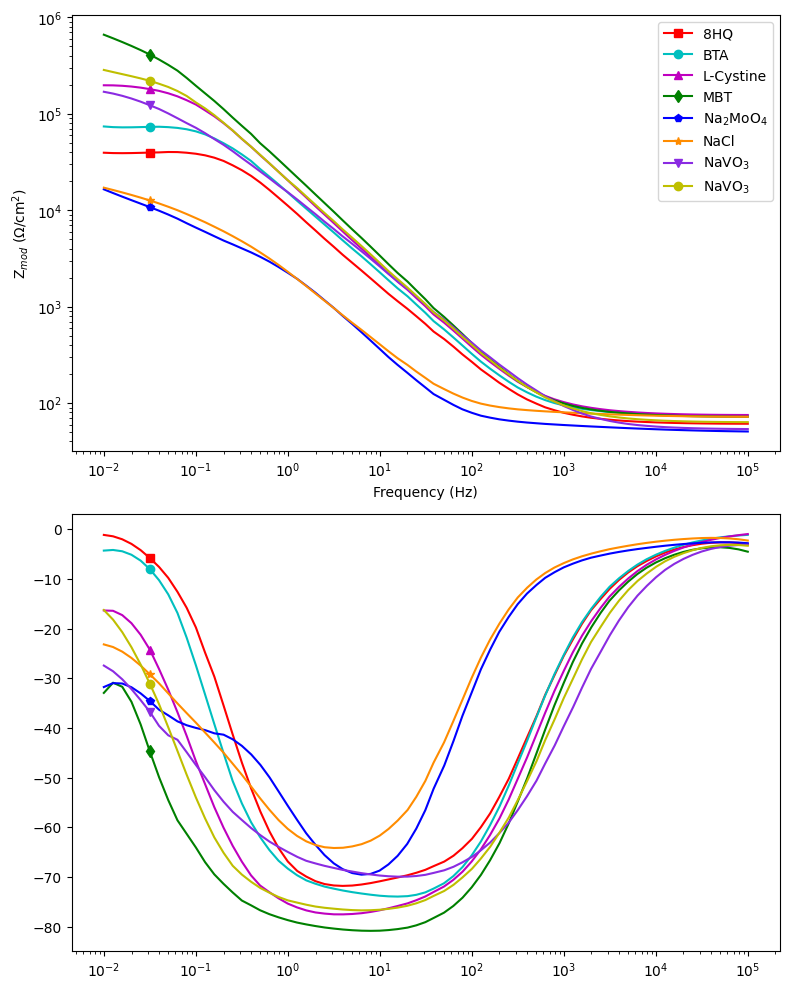

In [89]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize = (8,10))

for i, dataset in enumerate(all_datasets):
    #ax1.loglog(dataset['eis_data']['Freq'],dataset['eis_data']['Zmod'],label = dataset['eis_data_filtered']['name'])
    raw_name = dataset['eis_data_filtered']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax1.loglog(
        dataset['eis_data_filtered']['Freq'],
        dataset['eis_data_filtered']['Zmod'],
        label=label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         
        markersize=6,          
        markevery=(5,70)
    )
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
    ax1.legend()

for i, dataset in enumerate(all_datasets):
    #ax2.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'],label = dataset['eis_data_filtered']['name'])
    ax2.semilogx(
        dataset['eis_data_filtered']['Freq'],
        dataset['eis_data_filtered']['Zphz'],
        label = dataset['eis_data_filtered']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,70)
    )

plt.tight_layout()
plt.show()

[np.float64(13998.724706293704), np.float64(15743.997020979024), np.float64(39552.337832167934), np.float64(73614.34356643358), np.float64(149616.1341258742), np.float64(189147.84895104906), np.float64(272833.8786013986), np.float64(555174.7974825178)]


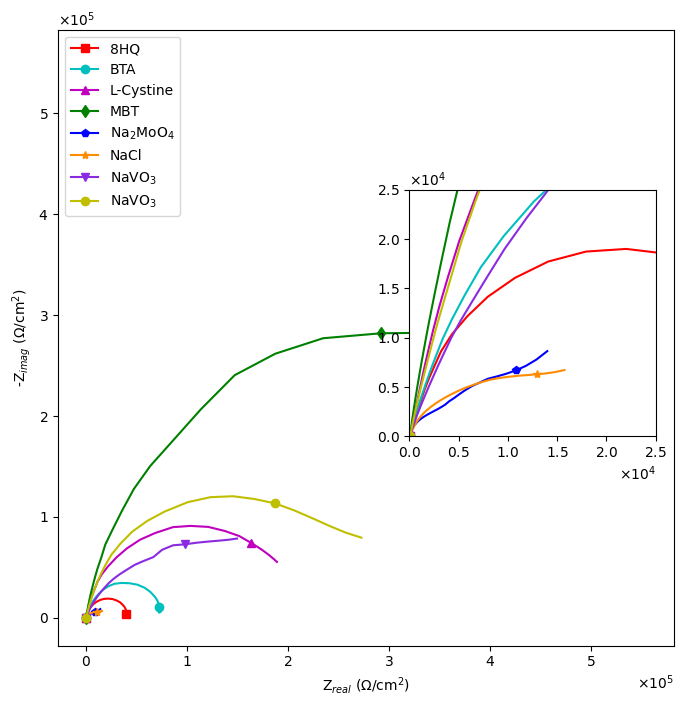

In [90]:
fig2, ax3 = plt.subplots(figsize=(8, 8))
axins = ax3.inset_axes([0.57, 0.34, 0.4, 0.4])
Max_Zreals = []
Max_Zimags = []

main_step = 100e3
inset_step = 5e3

for i, dataset in enumerate(all_datasets):
    raw_name = dataset['eis_data_filtered']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax3.plot(
        dataset['eis_data_filtered']['Zreal'],
        dataset['eis_data_filtered']['Zimag'],
        label = label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    ax3.legend(loc = 'upper left')
    ax3.xaxis.set_major_locator(MultipleLocator(main_step))
    ax3.yaxis.set_major_locator(MultipleLocator(main_step))
    ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    axins.plot(
        dataset['eis_data_filtered']['Zreal'],
        dataset['eis_data_filtered']['Zimag'],
        label = dataset['eis_data_filtered']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(3,65)
    )
    axins.xaxis.set_major_locator(MultipleLocator(inset_step))
    axins.yaxis.set_major_locator(MultipleLocator(inset_step))
    axins.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    max_Zreals = dataset['eis_data_filtered']['Zreal'].max()
    max_Zimags = dataset['eis_data_filtered']['Zimag'].max()
    Max_Zreals.append(max_Zreals)
    Max_Zimags.append(max_Zimags)


ax3.set_aspect('equal')
ax3.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)')
ax3.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)')


Max_Zreals.sort()
print(Max_Zreals)

axins.set_xlim(0, 25000)
axins.set_ylim(0, 25000)
#print(overall_min_inset,overall_max_inset)

x_min, x_max = ax3.get_xlim()
y_min, y_max = ax3.get_ylim()
overall_min = min(x_min, y_min)
overall_max = max(x_max, y_max)
ax3.set_xlim(overall_min, overall_max)
ax3.set_ylim(overall_min, overall_max)

plt.show()

